# Stats and visuals for the public spine

This is a pdf generated from a notebook, using the most recent version of the public spine. If anything is useful the graphs can be saved as pngs and accessed directly.

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
import upsetplot


In [2]:
basefilename = '/Users/fionack/Projects/TSO_project/public_spine_data/TSCS_spine'
#basefilename = '/Users/fionack/Projects/public_spine'
#basefilename = '/Users/fionack/Projects/TSO_project/tso-database-builder/main_spine.ccew.oscr.ccni.ch.csv'#main_spine.ccew.oscr'
spine_df = pd.read_csv(basefilename+'.spine.csv')#,usecols=['uid','normalisedname','registerdate'])
extras_df = pd.read_csv(basefilename+'.supplementary.csv',usecols=['uid','normalisedname','source_register'])
matches_df = pd.read_csv(basefilename+'.matches.csv',low_memory=False)

print(f'There are {spine_df.shape[0]} rows in the main spine, {extras_df.shape[0]} rows of supplementary data and {matches_df.shape[0]} matches found.\n')

#source_order = ['CCEW','OSCR','CCNI','CH','COOP','MPR' 'SHR','SHPE', 'CIS','CQC'  ]
source_order = {'CHC': 1, 
                'SC' : 2,
                'NIC': 3, 
                'COH' : 4,
                'COOP' : 5,
                'MPR' : 6,
                'SHR' : 7,
                'SHPE' : 8,
                'CIS' : 9,
                'CQC' : 10 }


/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_68264/3092684679.py:4: DtypeWarning: Columns (4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  spine_df = pd.read_csv(basefilename+'.spine.csv')#,usecols=['uid','normalisedname','registerdate'])


There are 769850 rows in the main spine, 798397 rows of supplementary data and 126695 matches found.



July 2025: There are 761923 rows in the main spine, 876626 rows of supplementary data and 108609 matches found.

Sept 2025 (data from Feb 2025): There are 753569 rows in the main spine, 895186 rows of supplementary data and 117007 matches found.

Nov 2025: There are 772256 rows in the main spine, 942571 rows of supplementary data and 126247 matches found.

Nov 2025 (after ccew algorithm edits): There are 772591 rows in the main spine, 715718 rows of supplementary data and 126120 matches found.

27Nov 2025 (after altering order to ingest mutuals before COH, and editing algorithm for umbrella orgs if they are removed (which was resulting in no postcodes for these orgs)) : There are 766735 rows in the main spine, 841520 rows of supplementary data and 125461 matches found.

5 Dec 2025 (after including OSCR's removed data): There are 766835 rows in the main spine, 841979 rows of supplementary data and 125454 matches found.

3 March 2026 (after some work tracking mergers, and deduplicating supplementary data): There are 769850 rows in the main spine, 798397 rows of supplementary data and 126695 matches found.

In [3]:
spine_df[spine_df['postcode'].isna()]['source_register'].value_counts()

source_register
Charity Commission for England and Wales    18903
Mutuals Public Register                      7435
Companies House                              2573
Social Housing England                        628
Scottish Charity Register                     206
Scottish Housing Regulator                    112
Charity Commission for Northern Ireland         8
Co-operatives                                   5
Name: count, dtype: int64

In [68]:
spine_df[spine_df['postcode'].isna()]['source_register'].value_counts()# & spine_df['fulladdress'].isna()]

source_register
Charity Commission for England and Wales    18022
Mutuals Public Register                      7435
Companies House                              2563
Social Housing England                        627
Scottish Charity Register                     206
Scottish Housing Regulator                    112
Charity Commission for Northern Ireland         8
Co-operatives                                   5
Name: count, dtype: int64

In [4]:
spine_df[spine_df['postcode'].isna() & spine_df['fulladdress'].isna() & (spine_df['source_register']=='Scottish Charity Register')]['uid']

370060    GB-SC-SC051907
370282    GB-SC-SC052148
370284    GB-SC-SC052150
370597    GB-SC-SC052504
370960    GB-SC-SC052899
371000    GB-SC-SC052942
371264    GB-SC-SC053216
371374    GB-SC-SC053328
371376    GB-SC-SC053330
371507    GB-SC-SC053462
371674    GB-SC-SC053634
371736    GB-SC-SC053696
371766    GB-SC-SC053727
371803    GB-SC-SC053764
371804    GB-SC-SC053765
371805    GB-SC-SC053766
371806    GB-SC-SC053767
371807    GB-SC-SC053768
371808    GB-SC-SC053769
371809    GB-SC-SC053770
371810    GB-SC-SC053771
371811    GB-SC-SC053772
371812    GB-SC-SC053773
371813    GB-SC-SC053774
371814    GB-SC-SC053775
371815    GB-SC-SC053776
372098    GB-SC-SC054059
372145    GB-SC-SC054106
372386    GB-SC-SC054348
374331    GB-SC-SC053525
377580    GB-SC-SC044666
379079    GB-SC-SC046774
379407    GB-SC-SC018496
379761    GB-SC-SC043500
379864    GB-SC-SC020724
379931    GB-SC-SC028150
380187    GB-SC-SC044278
380747    GB-SC-SC043822
381040    GB-SC-SC043988
Name: uid, dtype: object

## Counts per source in main spine

In [5]:

july_to_nov = {
'CHC'     :[346390,    349665,  349432],
'COH'     :[325403,    331723,  321919],
'SC'       :[52506,     53246,   53244],
'MPR'      :[19903,     19816,   32139],
'COOP'      :[9481,      9757,    8243],
'NIC'       :[8108,      8243,     651],
'SHR'        :[109,       111,     629],
'SHPE'        :[23,        30,     111],
}

july_to_nov_df = pd.DataFrame(july_to_nov).T
july_to_nov_df.reset_index(inplace=True)
july_to_nov_df.columns=['source','july2025','nov2025','27nov25']
july_to_nov_df['nov-jul'] = july_to_nov_df['nov2025'] - july_to_nov_df['july2025']
july_to_nov_df['27nov-jul'] = july_to_nov_df['27nov25'] - july_to_nov_df['july2025']

'''
Counts before the ccew update:
CHC   :[349432,],
COH   :[331756,],
SC    :[ 53245,],
MPR   :[ 19816,],
COOP  :[  9757,],
NIC   :[  8243,],
SHR   :[   111,],
SHPE  :[    31,],
'''

'\nCounts before the ccew update:\nCHC   :[349432,],\nCOH   :[331756,],\nSC    :[ 53245,],\nMPR   :[ 19816,],\nCOOP  :[  9757,],\nNIC   :[  8243,],\nSHR   :[   111,],\nSHPE  :[    31,],\n'

In [6]:

july_to_nov_df

,source,july2025,nov2025,27nov25,nov-jul,27nov-jul
0,CHC,346390,349665,349432,3275,3042
1,COH,325403,331723,321919,6320,-3484
2,SC,52506,53246,53244,740,738
3,MPR,19903,19816,32139,-87,12236
4,COOP,9481,9757,8243,276,-1238
5,NIC,8108,8243,651,135,-7457
6,SHR,109,111,629,2,520
7,SHPE,23,30,111,7,88


In [7]:
spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

spine_df['registerdate'] = pd.to_datetime(spine_df['registerdate'], errors='coerce', dayfirst=True)
spine_df[spine_df['basesource']=='SC']['registerdate'].max()

Timestamp('2025-12-04 00:00:00')

basesource
CHC     349572
COH     325166
SC       53339
MPR      32139
NIC       8243
COOP       651
SHPE       628
SHR        112
Name: count, dtype: int64
source_codes = {'CHC', 'COOP', 'SHPE', 'SC', 'SHR', 'COH', 'MPR', 'NIC'}
/Users/fionack/Projects/TSO_project/public_spine_data/TSCS_spine.sources.png


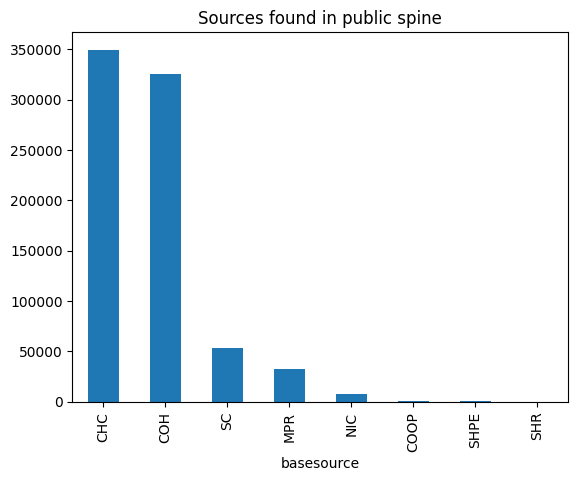

In [8]:

source_counts = spine_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
print(source_counts)
print(f"source_codes = {set(spine_df['basesource'])}")
source_counts.plot(kind='bar')
pyplot.title('Sources found in public spine')
print('%s.sources.png'%basefilename)
pyplot.savefig('%s.sources.png'%basefilename)


basesource
CHC     236752
COH     129277
SC       20820
COOP     10790
NIC       4697
CIS       2183
MPR       1571
CQC        986
SHPE       734
SHR         10
Name: count, dtype: int64


Text(0.5, 1.0, 'Sources found in supplementary data')

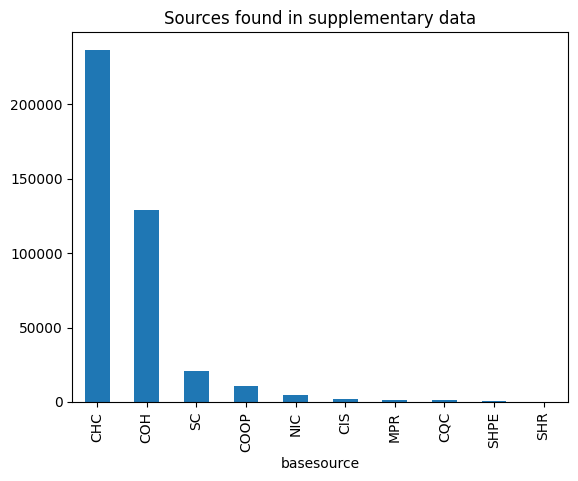

In [9]:
extras_df['basesource'] = extras_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

extras_sources = extras_df[['uid','basesource']].drop_duplicates()
extras_source_counts = extras_sources['basesource'].value_counts(dropna=False)
print(extras_source_counts)
extras_source_counts = extras_source_counts.rename(index={np.nan: 'NaN'})
extras_source_counts.plot(kind='bar')
pyplot.title('Sources found in supplementary data')


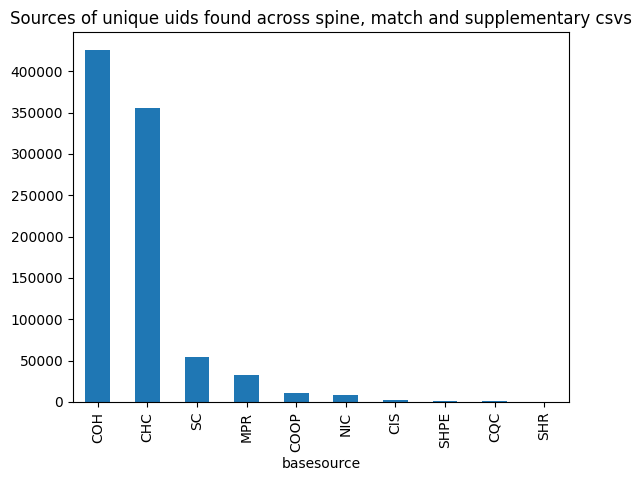

In [10]:
# find all uids used across all data:
uid_set = set(list(spine_df['uid']) + list(matches_df['orgA_uid']) + list(matches_df['orgB_uid']) + list(extras_df['uid']))

all_df = pd.DataFrame(uid_set,columns=['uid'])
#print(all_df)
all_df['basesource'] = all_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = all_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
#print(source_counts)
source_counts.plot(kind='bar')

pyplot.title('Sources of unique uids found across spine, match and supplementary csvs')

pyplot.savefig('%s.all.sources.png'%basefilename)

source_counts = [f"{source} & {count} \\\\ \\hline\n" for source, count in source_counts.items()]

with open(basefilename+'.all_used_orgs.tab.tex', 'w') as ofile:

    ofile.write('\\begin{table}[h]\n  \\centering\n')
    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Source & Count of orgs \\\\ \\hline \\hline\n')

    for i in source_counts:
        ofile.write(i)

    ofile.write('\\end{tabular}\n')
    ofile.write('\\caption{Count of organisations per source}\n')
    ofile.write('\\label{tab:all_used_orgs}\n')
    ofile.write('\\end{table}\n')





In [11]:
spine_uids = set(spine_df['uid'])
print(f'There are {len(spine_uids)} unique uids in the spine data')
matches_uids = set(matches_df['orgA_uid']) | set(matches_df['orgB_uid'])
matches_not_spine = matches_uids - spine_uids
print(f'There are {len(matches_not_spine)} unique uids in the matches data that are not in the spine data')

with open(basefilename + '.all_orgs.spine_match.tab.tex', 'w') as ofile:
    ofile.write('\\begin{tabular}{|l|r|r|r|}\n    \\hline\n')
    ofile.write(' & Count of orgs  & Count of orgs  & Total count\\\\ \n')
    ofile.write(' Source &  in spine & matched to spine & per source\\\\ \\hline \\hline\n')

    for i in source_order:
        
        count_in_spine = len([uid for uid in list(spine_uids) if f'GB-{i}' in uid])
        count_in_matches = len([uid for uid in list(matches_not_spine) if f'GB-{i}' in uid])
        print(f'Processing {i}: {count_in_spine} in spine, {count_in_matches} in matches')
        total = count_in_spine + count_in_matches
        ofile.write(f'{i} & {count_in_spine} & {count_in_matches} & {total}\\\\ \\hline\n')

    ofile.write('\\end{tabular}\n')

print('Table written to %s'%basefilename + '.all_orgs.spine_match.tab.tex')

There are 769850 unique uids in the spine data
There are 122869 unique uids in the matches data that are not in the spine data
Processing CHC: 349572 in spine, 6432 in matches
Processing SC: 53339 in spine, 1424 in matches
Processing NIC: 8243 in spine, 0 in matches
Processing COH: 325166 in spine, 100631 in matches
Processing COOP: 651 in spine, 10451 in matches
Processing MPR: 32139 in spine, 0 in matches
Processing SHR: 112 in spine, 47 in matches
Processing SHPE: 628 in spine, 715 in matches
Processing CIS: 0 in spine, 2183 in matches
Processing CQC: 0 in spine, 986 in matches
Table written to /Users/fionack/Projects/TSO_project/public_spine_data/TSCS_spine.all_orgs.spine_match.tab.tex


In [12]:
82716-74364+317051

325403

                 match_type  count
0                       ftc  70511
1  companyid - id_in_source  36616
2   companyid - coop mutual  10452
3                      oscr   4295
4               name - care   3650
5            name - housing    803
6     companyid - companyid    368


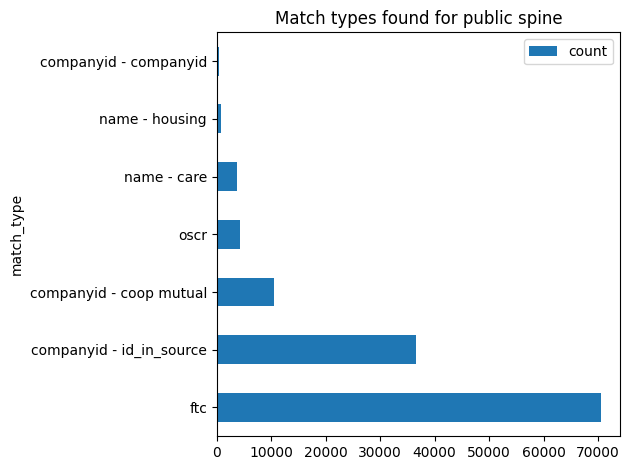

In [13]:

match_types = matches_df['match_type'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})
match_types = match_types.reset_index()
match_types.columns = ['match_type','count']

print(match_types)
match_types.plot(y='count', x='match_type', kind='barh')
pyplot.title('Match types found for public spine')
pyplot.tight_layout()
pyplot.savefig('%s.matchtypes.png'%basefilename)
pyplot.show()
# also think of how to plot this so that identical matches are shown in a different way - pairs of organisations which are matched by ftc and also name, for example - this chart doesn't differentiate



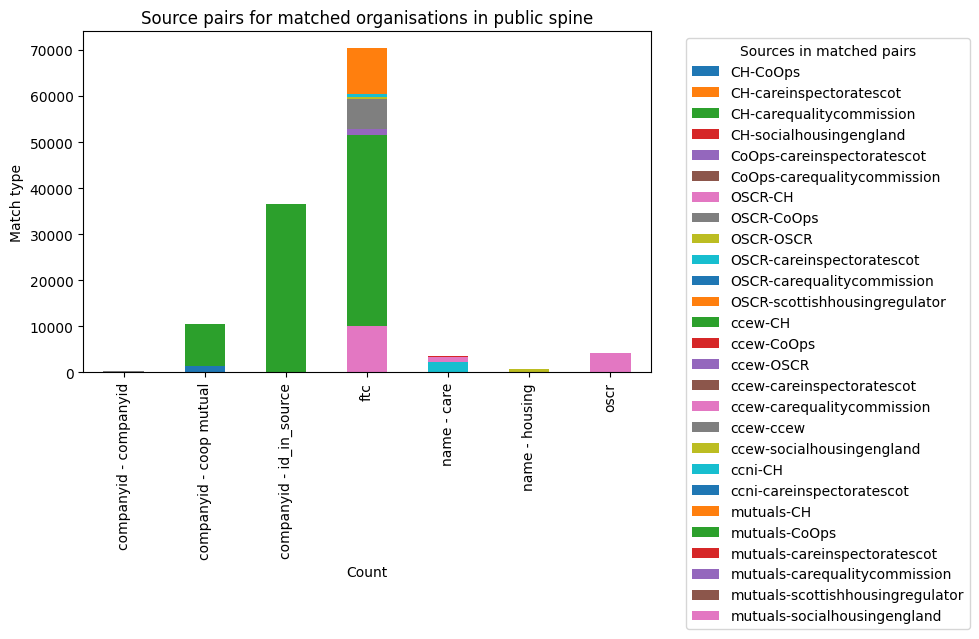

<Figure size 640x480 with 0 Axes>

In [14]:
matches_df['source-source'] = matches_df.apply(lambda row: '%s-%s'%(row['orgA_source'],row['orgB_source']), axis=1)
match_types = matches_df.groupby('match_type')['source-source'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})

# Convert Series to DataFrame for plotting
match_types = match_types.unstack().fillna(0)

# Plot the data
match_types.plot(kind='bar', stacked=True, figsize=(10, 6))
pyplot.title('Source pairs for matched organisations in public spine')
pyplot.legend(title='Sources in matched pairs', bbox_to_anchor=(1.05, 1), loc='upper left')
pyplot.xlabel('Count')
pyplot.ylabel('Match type')
pyplot.tight_layout()
pyplot.show()
pyplot.savefig('%s.match_source_pairs.types.png'%basefilename)

In [15]:
uids_in_matches_df = set(matches_df['orgA_uid'] + matches_df['orgB_uid'])
print(f'Unique uids in matches csv = {len(uids_in_matches_df)}')
print(f"Unique uids in main spine csv = {len(set(spine_df['uid']))}")

orga_uids = set(matches_df['orgA_uid'])
orgb_uids = set(matches_df['orgB_uid'])

print(f'Number of unique organisations in position OrgA = {len(orga_uids)}, and unique OrgB uids = {len(orgb_uids)}')

Unique uids in matches csv = 124151
Unique uids in main spine csv = 769850
Number of unique organisations in position OrgA = 106110, and unique OrgB uids = 123208


In [16]:
# code to generate the table used in release_info.tex
# with columns source  &  count in   &  count in     &  count in \\
#                      &  spine.csv  &  matches.csv  &  matches.csv \\


# Initialize an empty list to store the results
table_data = []

spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

matches_uids_df = pd.DataFrame(set(list(matches_df['orgA_uid'])+list(matches_df['orgB_uid'])),columns=['uid'])

matches_uids_df['basesource'] = matches_uids_df.apply(lambda row: row['uid'].split('-')[1], axis=1)


for source in source_order:
    # Get unique UIDs for the source in both dataframes
    spine_uids = spine_df.loc[spine_df['basesource'] == source, 'uid'].unique()
    matches_uids = matches_uids_df.loc[matches_uids_df['basesource'] == source, 'uid'].unique()

    # Calculate counts
    count_in_spine = len(spine_uids)
    count_in_matches = len(matches_uids)
    count_in_matches_not_spine = len(set(matches_uids) - set(spine_uids))

    # Append the data for the source
    table_data.append([source, count_in_spine, count_in_matches, count_in_matches_not_spine])


rows=[f'{i[0]} & {i[1]} & {i[2]} & {i[3]} \\\\' for i in table_data]

latex_table = (
    "\\begin{table}[h]\n"
    "\\centering\n"
    "\\begin{tabularx}{0.6\\textwidth}{|X|r|r|r|}\n"
    "\\hline\n"
    "source & count in & count in & count in \\\\\n"
    "& spine.csv &  matches.csv &  matches.csv \\\\\n"
    "&&& not spine.csv \\\\\n"
    +'\n'.join(rows)
    +"\\hline\n"
    "\\end{tabularx}\n"
    "\\caption{Counts of unique uids in spine and matches csvs}\n"
    "\\end{table}\n"
)

# Print the LaTeX table


print(latex_table)





\begin{table}[h]
\centering
\begin{tabularx}{0.6\textwidth}{|X|r|r|r|}
\hline
source & count in & count in & count in \\
& spine.csv &  matches.csv &  matches.csv \\
&&& not spine.csv \\
CHC & 349572 & 85632 & 6432 \\
SC & 53339 & 14034 & 1424 \\
NIC & 8243 & 656 & 0 \\
COH & 325166 & 102096 & 100631 \\
COOP & 651 & 10496 & 10451 \\
MPR & 32139 & 12473 & 0 \\
SHR & 112 & 47 & 47 \\
SHPE & 628 & 715 & 715 \\
CIS & 0 & 2183 & 2183 \\
CQC & 0 & 986 & 986 \\\hline
\end{tabularx}
\caption{Counts of unique uids in spine and matches csvs}
\end{table}



Find the numbers of matches found by any combination of match types:

In [17]:
match_types_dict = {}  #
uid_uid_match_dict = {}
#print(matches_df)                   
matches_df['uid-uid'] = matches_df.apply(lambda row: '%s:%s' % tuple(sorted([row['orgA_uid'], row['orgB_uid']])), axis=1)
#print(matches_df)
#
unique_uidA_uidB = set(matches_df['uid-uid'])
#print(unique_uidA_uidB)
print(f'Number of uniquely matched pairs of orgs in matches csv = {len(unique_uidA_uidB)} (of {matches_df.shape[0]} rows in matches csv)')
print(f' ==> number of org pairs found in multiple ways = {matches_df.shape[0]-len(unique_uidA_uidB)}')
#matches_df['uid-uid'].value_counts()



Number of uniquely matched pairs of orgs in matches csv = 124151 (of 126695 rows in matches csv)
 ==> number of org pairs found in multiple ways = 2544


In [18]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import upsetplot
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


source_order = {'CHC': 1, 
                'SC' : 2,
                'NIC': 3, 
                'COH' : 4,
                'COOP' : 5,
                'MPR' : 6,
                'SHR' : 7,
                'SHPE' : 8,
                'CIS' : 9,
                'CQC' : 10 }

def plot_upset_matches_multi(basefilename,include = 'all'):#_unmatched_orgs=True,only_unmatched_orgs=False):
    if not include in ['all','only_matched','only_unmatched']:
        raise ValueError("Invalid argument for include, must be in ['all','only_matched','only_unmatched']")

    # Read input files
    #all_uids = pd.read_csv(basefilename + '.spine.csv', usecols=['uid'])
    #matches_df = pd.read_csv(basefilename + '.matches.csv')

    all_uids = pd.read_csv(basefilename + '.spine.csv', usecols=['uid'], dtype={'uid': str})
    matches_df = pd.read_csv(basefilename + '.matches.csv', usecols=['orgA_uid','orgB_uid'],dtype=str, low_memory=False)

    
    # Create a dictionary to map each uid to its matches
    match_dict = {}
    

    for index, row in matches_df.iterrows():
        orgA_uid, orgB_uid = row['orgA_uid'], row['orgB_uid']
        if orgA_uid not in match_dict:
            match_dict[orgA_uid] = set()
        if orgB_uid not in match_dict:
            match_dict[orgB_uid] = set()
        match_dict[orgA_uid].add(orgB_uid)
        match_dict[orgB_uid].add(orgA_uid)
    
    def find_matches(uid):
        # Use an iterative approach to find all matches
        found = set()
        stack = [uid]
        while stack:
            current = stack.pop()
            if current not in found:
                found.add(current)
                stack.extend(match_dict.get(current, []))
        return found
    
    # Process each uid and find all matched uids
    m_list = []
    for uid in all_uids['uid']:
        matched = find_matches(uid)
        matched.add(uid)
        try:
            sources = [i.split('-')[1] for i in matched]
            m_list.append(sources)
        except Exception as e:
            print(f'{e}: uid = {uid}, matched = {matched}')
    
    # Create a DataFrame for the upset plot
    series = pd.Series(m_list)
    source_list = list(source_order.keys())
    df = pd.DataFrame({item: series.apply(lambda x: item in x) for item in source_list})
    
    # Group by source_list and get the size
    df_grouped = df.groupby(source_list).size()
    
    if include == 'only_matched':
    # Filter out rows with only one 'true' value
        df_grouped = df_grouped[df_grouped.index.map(sum) > 1]

    if include == 'only_unmatched':
        df_grouped = df_grouped[df_grouped.index.map(sum) ==1]
    
    
    # Plot using upsetplot
    upsetplot.plot(df_grouped, orientation='horizontal')
    if include == 'all':
        plt.title("Data sources used for each organisation found in %s" % os.path.basename(basefilename).replace('_',' ').capitalize())
        plt.savefig('%s.all_orgs.upsetplot.png' % basefilename)
    elif include == 'only_matched':
        plt.title("Data sources for matched organisations only, found in %s" % os.path.basename(basefilename).replace('_',' ').capitalize())
        plt.savefig('%s.matched_orgs.upsetplot.png' % basefilename)
    elif include == 'only_unmatched':
        plt.title("Data sources for organisations found in one source only")
        plt.savefig('%s.unmatched.upsetplot.png' % basefilename)
    
    plt.show()
    return df_grouped




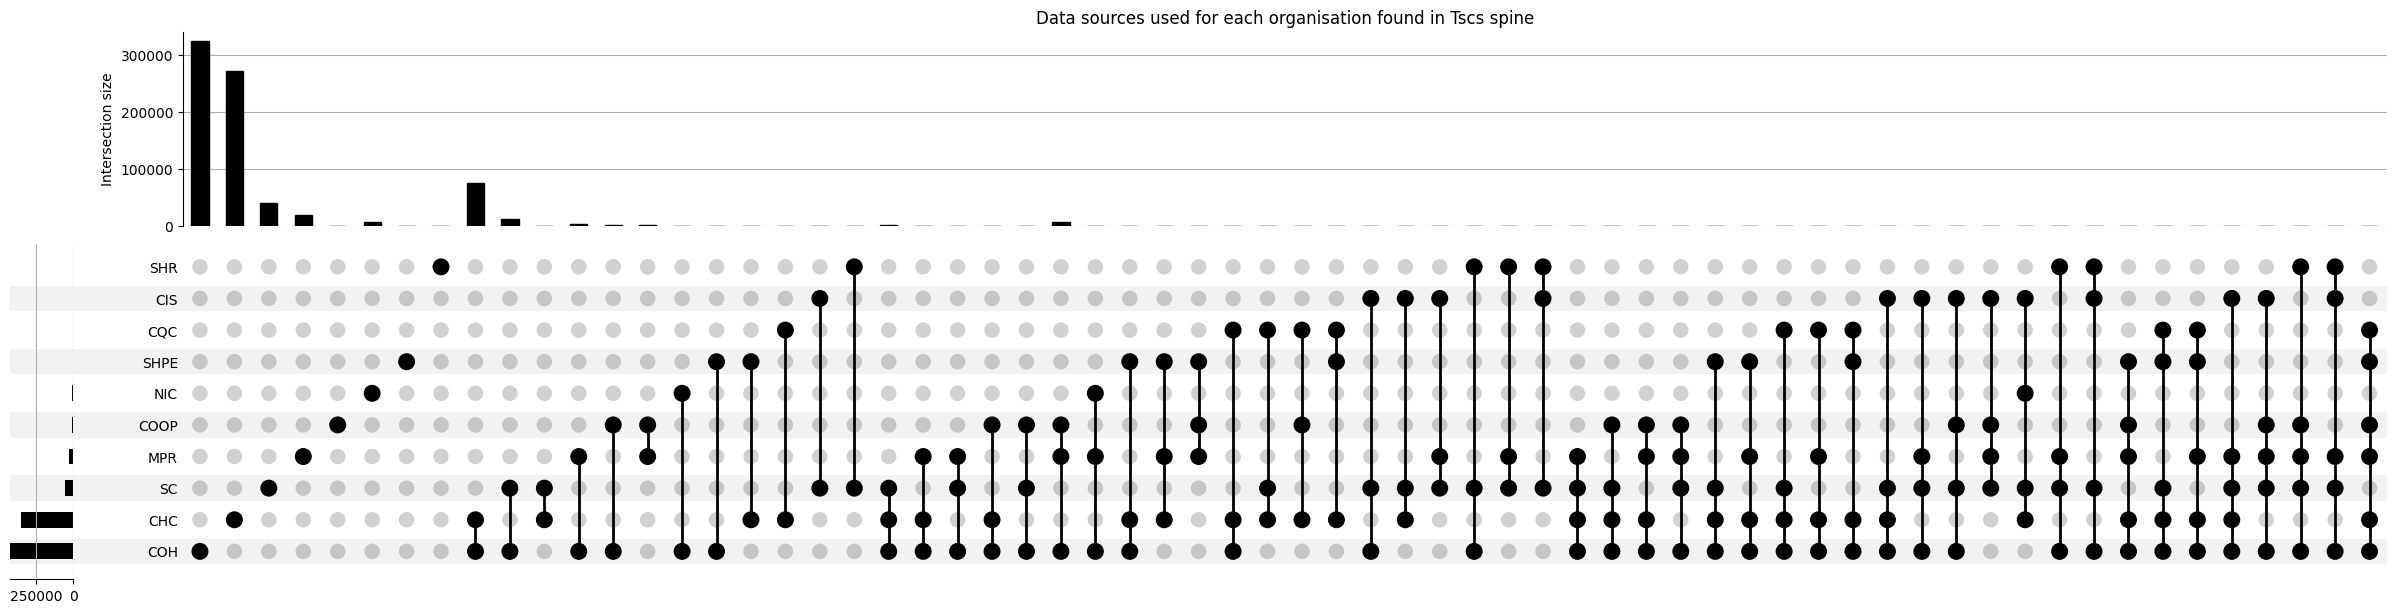

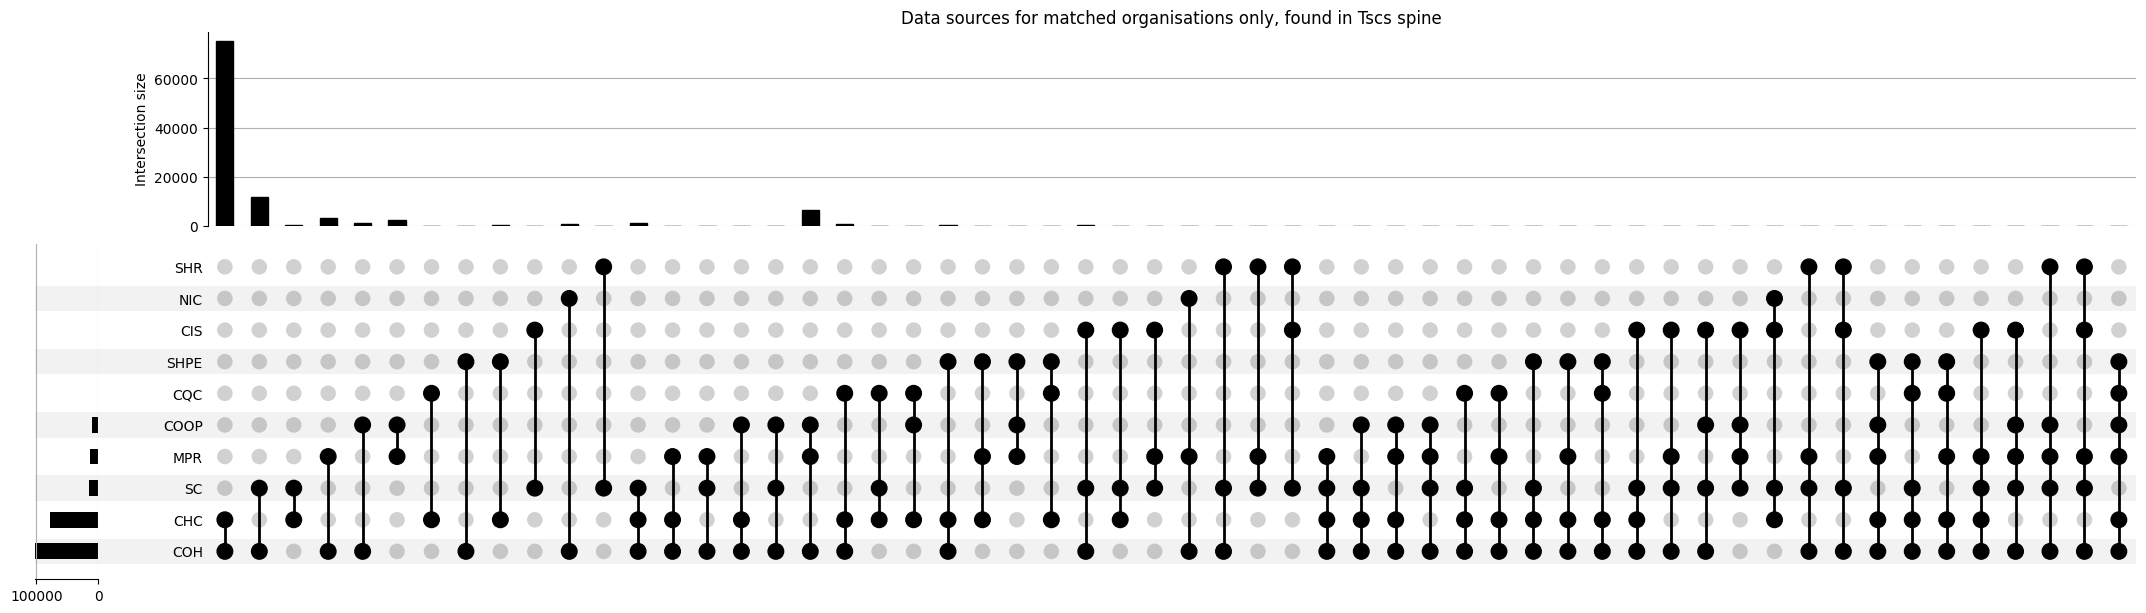

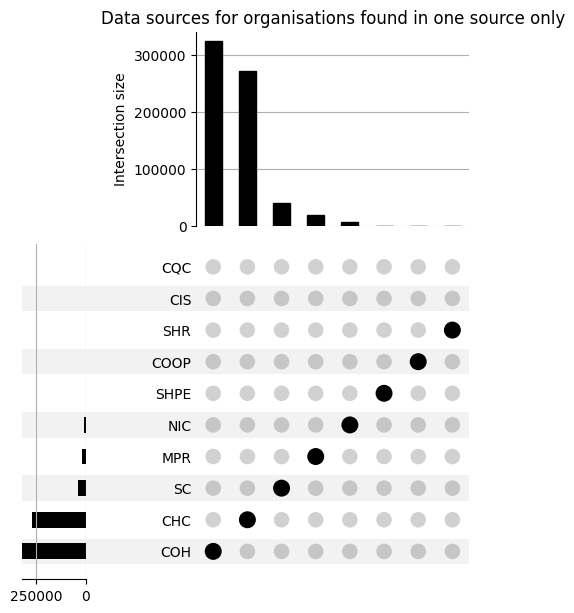

In [19]:
a=plot_upset_matches_multi(basefilename,'all')
b=plot_upset_matches_multi(basefilename,'only_matched')
c=plot_upset_matches_multi(basefilename,'only_unmatched')

Plotting the organisations matched in more than one way through our algorithm:

Text(0, 0.5, 'Count of org pairs matched')

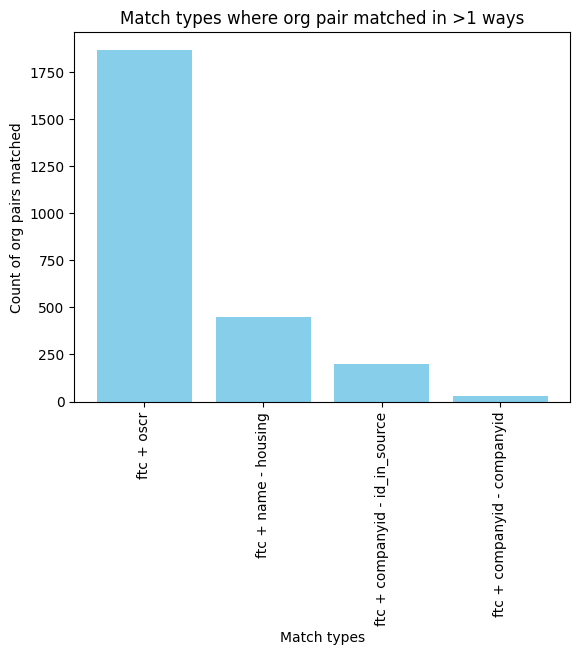

In [20]:

# plot the orgs matched in multiple ways:

def concat_strings(series):
    return ' + '.join(series)


concatenated = matches_df.groupby('uid-uid')['match_type'].apply(concat_strings).reset_index()
concatenated.columns = ['uid-uid','match_type']


counts = matches_df['uid-uid'].value_counts().reset_index()
counts.columns = ['uid-uid', 'count']


result = pd.merge(concatenated, counts, on='uid-uid')

two_matches= result[result['count']>1]
match_type_counts = two_matches['match_type'].value_counts().reset_index()
match_type_counts.columns = ['match_type', 'count']
pyplot.bar(match_type_counts['match_type'], match_type_counts['count'], color='skyblue')
pyplot.xticks(rotation=90)
pyplot.title('Match types where org pair matched in >1 ways')
pyplot.xlabel('Match types')
pyplot.ylabel('Count of org pairs matched')

#pyplot.bar(two_matches['match_type'],height=two_matches.groupby['match_type'].value_counts())



Counts of companies house legal forms. Need to map spine back onto CH data to include the companytype information (this is lost in pre-processing as we only care about overall source at that stage).

In [21]:
raw_ch_df = pd.read_csv('../../raw_data/CH.all.csv',usecols=['uid','companytype'])
print(raw_ch_df.shape)
raw_ch_df.drop_duplicates(inplace=True)
print(raw_ch_df.shape)

(5108832, 2)
(662885, 2)


In [22]:

def cic_mapping(s):
    if 'community-interest-company' in s:
        return 'Community Interest Company'
    if 'private-limited-guarant' in s or 'CLG' in s or 'PRI/LTD BY GUAR/NSC' in s or 'PRI/LBG/NSC' in s: 
        return 'Company Limited by Guarantee'
    else: return s

raw_ch_df['compressed_source'] = raw_ch_df['companytype'].apply(cic_mapping)

In [23]:
source_df = raw_ch_df['companytype'].value_counts()
source_df_sorted_by_source = source_df.sort_index()

source_df.sort_index()
source_df_sorted_by_source.sort_values(ascending=False, inplace=True)
print(source_df_sorted_by_source)
# output the source_df_sorted_by_source to a latex table
source_df_sorted_by_source.to_latex('../CH.companytype.tab.tex')
with open('../CH.companytype.tab.tex', 'w') as ofile:

    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Company type & Count \\\\ \\hline \\hline\n')

    for i in source_df_sorted_by_source.items():
        ofile.write(f'{i[0]} & {i[1]} \\\\ \\hline\n')

    ofile.write('\\end{tabular}\n')



companytype
private-limited-guarant-nsc                                                                  221982
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                        143448
private-limited-guarant-nsc-limited-exemption                                                 70733
private-limited-guarant-nsc community-interest-company                                        61079
Community Interest Company                                                                    51018
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)     42814
Charitable Incorporated Organisation                                                          41410
Registered Society                                                                            11200
ltd community-interest-company                                                                11189
Scottish Charitable Incorporated Organisation                                           

compressed_source
Charitable Incorporated Organisation              41410
Community Interest Company                       123588
Company Limited by Guarantee                     478977
Industrial and Provident Society                    162
Registered Society                                11200
Scottish Charitable Incorporated Organisation      7548
Name: count, dtype: int64


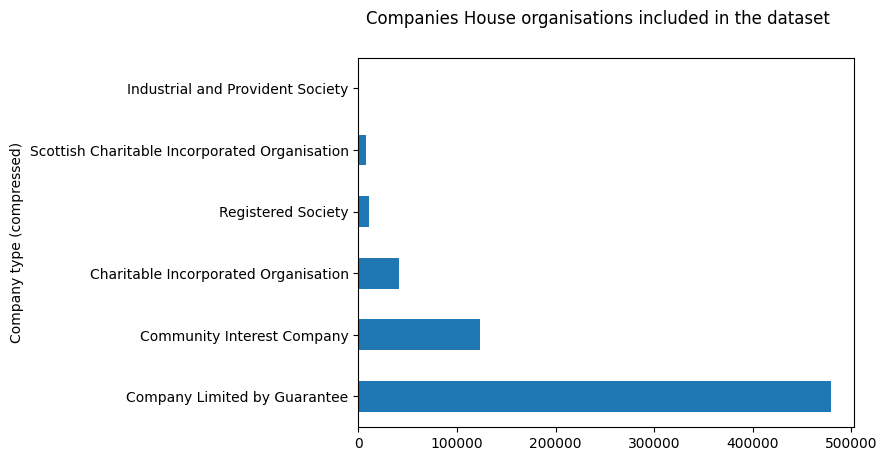

In [24]:
source_df = raw_ch_df['compressed_source'].value_counts()
source_df_sorted_by_source = source_df.sort_index()

source_df.sort_index()
print(source_df_sorted_by_source)
source_df_sorted_by_source.sort_values(ascending=False, inplace=True)
source_df.plot(kind='barh')
pyplot.suptitle('Companies House organisations included in the dataset')
pyplot.ylabel('Company type (compressed)')
pyplot.savefig('../CH_dist.png',bbox_inches='tight')

with open('../CH_dist.tab.tex', 'w') as ofile:

    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Company type & Count \\\\ \\hline \\hline\n')

    for i in source_df_sorted_by_source.items():
        ofile.write(f'{i[0]} & {i[1]} \\\\ \\hline\n')

    ofile.write('\\end{tabular}\n')


In [25]:
# preprocessed CH data:
subspine_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.csv')
supp_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.supplementary.csv')


/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_68264/3635633977.py:2: DtypeWarning: Columns (8,14) have mixed types. Specify dtype option on import or set low_memory=False.
  subspine_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.csv')
/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_68264/3635633977.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  supp_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.supplementary.csv')


In [26]:
len(subspine_ch_df['uid'].unique())

425797

In [27]:
len(supp_ch_df['uid'].unique())

81798

In [28]:
s={'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 362311, 'CoOps': 9195, 'mutuals': 18649, 'ScottishHousingRegulator': 158, 'SocialHousingEngland': 9, 'CareInspectorateScot': 1582, 'CareQualityCommission': 35654}
m={'CCEW': 5191, 'CH': 74964, 'SocialHousingEngland': 1981, 'CareQualityCommission': 1376, 'OSCR': 1569, 'CCNI': 1, 'CareInspectorateScot': 2689, 'CoOps': 1368, 'mutuals': 20102}
t=920734

In [29]:
import re
def normalise_postcode(postcode):
    '''normalise postcode to upper case, remove spaces and hyphens'''
    postcode = postcode.replace('-',' ').strip()
    postcode = re.sub(r'\s+', ' ', postcode)
    postcode = postcode.upper()
    
    postcode_regex = re.compile(r"^(GIR 0AA|[A-Z]{1,2}[0-9][0-9A-Z]? ?[0-9][A-Z]{2})$", re.IGNORECASE)
    partial_pc_regex = re.compile(r"^([A-Z]{1,2}[0-9][0-9A-Z]? ?[0-9]?[A-Z]?)$", re.IGNORECASE)
    if not postcode_regex.match(postcode):
        if partial_pc_regex.match(postcode):
            postcode = postcode
        else:
            postcode = ''
    return postcode                    